In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import mediapipe as mp
from keras import layers
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import load_model
from mediapipe.tasks.python.vision import face_landmarker


In [2]:
import torch
torch.cuda.is_available()

True

In [ ]:
# FaceLandmarker
base_options = python.BaseOptions(model_asset_path='../face_landmarker_v2_with_blendshapes.task')
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)

TRAIN_DATA_PATH = os.path.join("../affectnet_dataset/Train")
TEST_DATA_PATH = os.path.join("../affectnet_dataset/Test")
EPOCHS = 50
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (75,75)
EMOTIONS = [d for d in os.listdir(TRAIN_DATA_PATH) if d != '.DS_Store']
SAVED_MODEL = "../saved_models/mlp_weighted_model.h5"

keypoints_dir = "../keypoints_dataset_2"

data_dirs = {
    "train": TRAIN_DATA_PATH,
    "test": TEST_DATA_PATH
}

os.makedirs(keypoints_dir, exist_ok=True)

In [4]:
EMOTIONS

['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [31]:

def extract_keypoints(results):
    if results.face_landmarks:
        face = np.array(
            [[lm.x, lm.y, lm.z] for lm in results.face_landmarks.landmark]
        )

        # center
        center = face.mean(axis=0)
        face = face - center

        # scale normalize
        scale = np.linalg.norm(face.max(axis=0) - face.min(axis=0))
        if scale != 0:
            face = face / scale

        return face.flatten()
    else:
        return np.zeros(468 * 3)

In [20]:
# for split, split_dir in data_dirs.items():
#     for class_name in sorted(os.listdir(split_dir)):
#         class_path = os.path.join(split_dir, class_name)
#         if not os.path.isdir(class_path):
#             continue

#         save_class_path = os.path.join(keypoints_dir, split, class_name)
#         os.makedirs(save_class_path, exist_ok=True)

#         for img_name in os.listdir(class_path):
#             if img_name.startswith("."):
#                 continue

#             img_path = os.path.join(class_path, img_name)

#             img = cv2.imread(img_path)
#             if img is None:
#                 continue

#             img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#             img = cv2.resize(img, (75, 75))

#             mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)

#             results = detector.detect(mp_image)

#             if results.face_landmarks:
#                 face_landmarks = results.face_landmarks[0]
#                 keypoints = np.array([[lm.x, lm.y, lm.z] for lm in face_landmarks])
#             else:
#                 keypoints = np.zeros((468, 3))

#             save_path = os.path.join(
#                 save_class_path,
#                 img_name.split('.')[0] + ".npy"
#             )
#             np.save(save_path, keypoints)

# print("Keypoints saved in folder:", keypoints_dir)

Keypoints saved in folder: ../keypoints_dataset_2


In [32]:
folder = "../keypoints_dataset_2/train/contempt"

# List all .npy files
files = [f for f in os.listdir(folder) if f.endswith(".npy")]

first_img = os.path.join(folder, files[0])
keypoints = np.load(first_img)
print(keypoints.shape)

(478, 3)


In [33]:
# Load keypoints arrays
def load_keypoints_dataset(base_dir):
    X, y = [], []
    for class_name in sorted(os.listdir(base_dir)):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in os.listdir(class_path):
            if not file.endswith(".npy"):
                continue
            keypoints = np.load(os.path.join(class_path, file))
            X.append(keypoints)
            y.append(class_name)
    return np.array(X), np.array(y)

X, y = load_keypoints_dataset("../keypoints_dataset/train")

le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y)

# Split FIRST
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# THEN standardize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
print(X_train.shape, y_train.shape)

(12886, 1404) (12886, 8)


In [34]:
# Weight parameter in CrossEntropyLoss function to apply a weight to each class based on its frequency
y_labels = np.argmax(y_train, axis=1)
# class weights will be given by
# n_samples / (n_classes * np.bincount(y))
# np.bincount counts the occurrences of value in an input array
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)
weights = dict(zip(np.unique(y_labels), class_weights_array))
print("Class weights array:", weights)

Class weights array: {np.int64(0): np.float64(1.3356135986733002), np.int64(1): np.float64(1.2834661354581673), np.int64(2): np.float64(1.6588568486096806), np.int64(3): np.float64(1.3170482420278005), np.int64(4): np.float64(0.8636729222520108), np.int64(5): np.float64(0.7338268792710706), np.int64(6): np.float64(0.6466278602970694), np.int64(7): np.float64(0.9587797619047619)}


In [5]:
num_classes = y_train.shape[1]

model = tf.keras.Sequential([
    layers.Input(shape=(1404,)),
# higher dropout 
    layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(64, activation='relu'),

    layers.Dense(8, activation='softmax')
])

optimizer = Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

NameError: name 'y_train' is not defined

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
mc = ModelCheckpoint(SAVED_MODEL, monitor='val_accuracy', save_best_only=True)
csv_logger = CSVLogger('../logs/mlp_weighted_loss_training_log.csv')

In [37]:
import time
start = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=weights,
    callbacks=[es, mc, csv_logger]
)
end = time.time()

print("Training time: ", (end - start)/60)

Epoch 1/50
400/403 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2575 - loss: 2.0941

403/403 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.3088 - loss: 1.9778 - val_accuracy: 0.3957 - val_loss: 1.7409
Epoch 2/50
401/403 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3763 - loss: 1.8249

403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.3747 - loss: 1.8175 - val_accuracy: 0.4382 - val_loss: 1.6464
Epoch 3/50
401/403 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3839 - loss: 1.7815

403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.3879 - loss: 1.7748 - val_accuracy: 0.4503 - val_loss: 1.6125
Epoch 4/50
400/403 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3973 - loss: 1.7455

403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.3983 - loss: 1.7394 - val_accuracy: 0.4531 - val_loss: 1.5863
Epoch 5/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4032 - loss: 1.7217 - val_accuracy: 0.4531 - val_loss: 1.5830
Epoch 6/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4142 - loss: 1.7037 - val_accuracy: 0.4308 - val_loss: 1.6007
Epoch 7/50
401/403 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4162 - loss: 1.7050

403/403 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.4111 - loss: 1.7031 - val_accuracy: 0.4575 - val_loss: 1.5866
Epoch 8/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.4135 - loss: 1.6980 - val_accuracy: 0.4503 - val_loss: 1.5724
Epoch 9/50
401/403 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4191 - loss: 1.6902

403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4160 - loss: 1.6802 - val_accuracy: 0.4696 - val_loss: 1.5556
Epoch 10/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4194 - loss: 1.6853 - val_accuracy: 0.4674 - val_loss: 1.5560
Epoch 11/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4173 - loss: 1.6810 - val_accuracy: 0.4634 - val_loss: 1.5630
Epoch 12/50
399/403 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4217 - loss: 1.6787

403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4194 - loss: 1.6733 - val_accuracy: 0.4730 - val_loss: 1.5522
Epoch 13/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4257 - loss: 1.6698 - val_accuracy: 0.4718 - val_loss: 1.5435
Epoch 14/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4252 - loss: 1.6728 - val_accuracy: 0.4718 - val_loss: 1.5480
Epoch 15/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.4280 - loss: 1.6633 - val_accuracy: 0.4609 - val_loss: 1.5680
Epoch 16/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.4226 - loss: 1.6674 - val_accuracy: 0.4665 - val_loss: 1.5313
Epoch 17/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4279 - loss: 1.6597 - val_accuracy: 0.4528 - val_loss: 1.5566
Epoch 18/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4255 - loss: 1.6630 - val_accuracy: 0.4662 - val_loss: 1.5524
Epoch 19/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.4245 - loss: 1.6618 - val_accuracy

403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4330 - loss: 1.6589 - val_accuracy: 0.4789 - val_loss: 1.5345
Epoch 26/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4301 - loss: 1.6504 - val_accuracy: 0.4714 - val_loss: 1.5386
Training time:  3.163365129629771


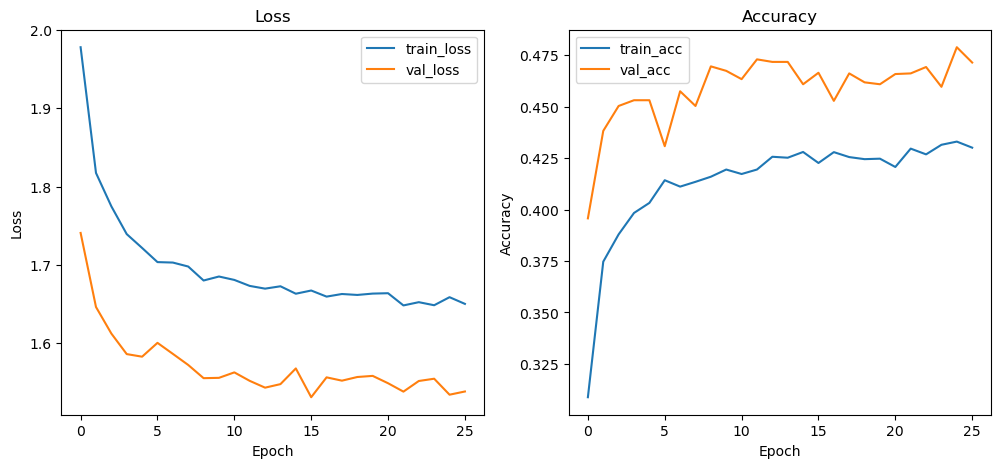

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [6]:
model = load_model(SAVED_MODEL)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../saved_models/mlp_weighted_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [41]:
def load_keypoints_dataset(base_dir):
    X, y = [], []
    for class_name in sorted(os.listdir(base_dir)):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in os.listdir(class_path):
            if not file.endswith(".npy"):
                continue
            keypoints = np.load(os.path.join(class_path, file))
            X.append(keypoints)
            y.append(class_name)
    return np.array(X), np.array(y)

# load test data
X_test, y_test = load_keypoints_dataset("../keypoints_dataset/test")

# Encode labels using  same LabelEncoder as training
# `le` is label encoder fitted on training labels
y_test_enc = le.transform(y_test) 
y_test_cat = to_categorical(y_test_enc)  # one-hot

# scaler is the StandardScaler fitted on training data
# scalar.transform() standardizes test features using training mean and std
X_test = scaler.transform(X_test)

print("X_test shape:", X_test.shape)
print("y_test_cat shape:", y_test_cat.shape)

X_test shape: (14518, 1404)
y_test_cat shape: (14518, 8)


In [42]:
# Predict probabilities
yhat_probs = model.predict(X_test)  # shape (num_samples, 8)

# Convert probabilities to predicted class indices
yhat = np.argmax(yhat_probs, axis=1)

# True class indices
ytrue = np.argmax(y_test_cat, axis=1)  # one-hot

454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


In [43]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(ytrue, yhat)
print(f"Test Accuracy: {acc*100:.2f}%")

Test Accuracy: 48.89%
